# Exercise 1 

In this exercise, we will work with the `spam.csv` data file. This file contains text and a label attached to each text. The goal is to explore this data. 

### Exercise 1(a) (2 points)

Load the `pandas` and `numpy` libraries.

In [1]:
import pandas as pd
import numpy as np

### Exercise 1(b) (2 points)

Read the `csv` file and create a data-frame called `spam_df`.

In [2]:
spam_df = pd.read_csv('spam.csv')
spam_df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Exercise 1(c) (2 points)

Report the `shape` of `spam_df`.

In [3]:
spam_df.shape

(5572, 2)

### Exercise 1(d) (2 points)

Report the frequency table of `label`.

In [4]:
spam_df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [5]:
spam_df["label"].value_counts(normalize=True)

label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

### Exercise 1(e) (2 points)

Using the `string` library, remove all the punctuation of the `text` column.

In [6]:
spam_df["text"][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [7]:
import string

spam_df["text_clean"] = spam_df["text"].str.replace(f"[{string.punctuation}]", "", regex=True)
spam_df.head()

,label,text,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...


In [8]:
import string

string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

### Exercise 1(f) (10 points)

Using the `nltk` library, remove stopwords and pronouns from `text_clean` and store in another column called `'text_clean_1'`. If you don't have `nltk` installed in your computer, run the following code:

```
pip install nltk
```

In [9]:
!pip install nltk


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\isabe_8m\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
pronouns = {"i", "me", "my", "mine", "you", "your", "yours", "he", "him", "his", "she", "her", "hers", "it", "its", "we", "us", "our", "ours", "they", "them", "their", "theirs"}

def clean_text(text):

    # Tokenize the text
    words = word_tokenize(text)

    # Remove stop words and pronouns
    cleaned_words = [word for word in words if word.lower() not in stop_words and word.lower() not in pronouns]
    return " ".join(cleaned_words)

spam_df["text_clean_1"] = spam_df["text"].apply(clean_text)
spam_df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\isabe_8m\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\isabe_8m\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\isabe_8m\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


,label,text,text_clean,text_clean_1
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"Go jurong point , crazy .. Available bugis n g..."
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,Ok lar ... Joking wif u oni ...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry 2 wkly comp win FA Cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,U dun say early hor ... U c already say ...
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"Nah n't think goes usf , lives around though"


### Exercise 1(g) (3 points)

Split the `spam_df` based on `label` into two data-frames called: `ham` and `spam`.

In [12]:
ham = spam_df[spam_df["label"] == "ham"].reset_index(drop=True)
spam = spam_df[spam_df["label"] == "spam"].reset_index(drop=True)


### Exercise 1(h) (5 points)

Create a word-cloud of `text_clean_1` from the `ham` data-frame. If you have the `wordcloud` library installed, run the following code:

```
pip install wordcloud
```

In [ ]:
!pip install wordcloud


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\isabe_8m\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


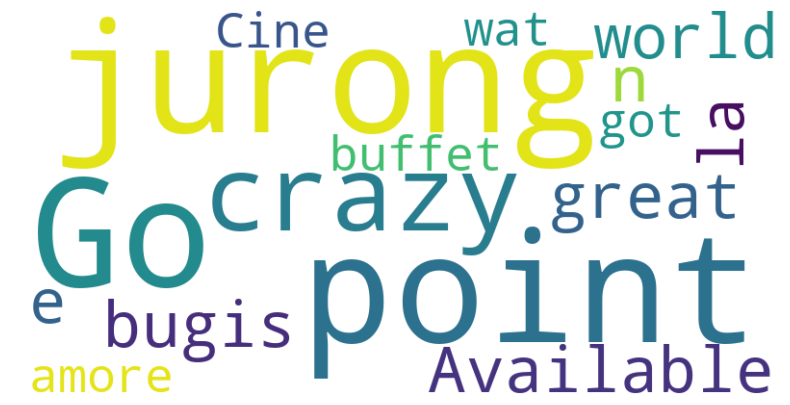

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham["text_clean_1"][0])
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Exercise 1(i) (5 points)

Create a word-cloud of `text_clean_1` from the `spam` data-frame. 

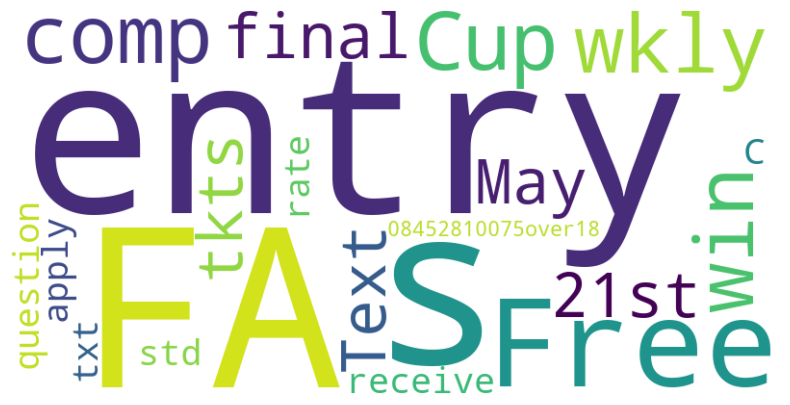

In [16]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam["text_clean_1"][0])
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()